<a href="https://colab.research.google.com/github/fauzyy2948-del/UTS-BIG_DATA-AHMAD_FAUZY-14022300036/blob/main/UTS-BIG_DATA-AHMAD_FAUZY-14022300036.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
pip install google_play_scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.4 MB/s eta 0:00:00


In [8]:
from google_play_scraper import reviews, Sort
import csv

result, _ = reviews(
    'com.kai.kaiticketing',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=100,
    filter_score_with=None
)

filename = 'ulasan_google_play.csv'


with open(filename, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['userName', 'score', 'at', 'content'])
    writer.writeheader()
    for review in result:

        writer.writerow({
            'userName': review['userName'],
            'score': review['score'],
            'at': review['at'],
            'content': review['content']
        })

print(f"Berhasil menyimpan {len(result)} ulasan ke '{filename}'")

Berhasil menyimpan 100 ulasan ke 'ulasan_google_play.csv'


In [9]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

First, let's load the saved reviews from the CSV file into a pandas DataFrame.

In [10]:
df = pd.read_csv('ulasan_google_play.csv')
display(df.head())

,userName,score,at,content
0,Vatur RM,1,2026-05-05 02:41:22,update aplikasi baru. reduksi jadi hilang. nam...
1,Dino arianto,1,2026-05-05 02:34:28,apa si harus nunggu kode sebelum brangkat 2 ja...
2,jeppnineteen,5,2026-05-05 02:19:52,oke lah
3,Danny Darsan,3,2026-05-05 01:04:48,kereta api supas jam 2 pagi tujuan gubeng poro...
4,Mooca Developer,1,2026-05-04 22:37:42,"Aplikasi terbaru Mei 2026 jadi ngebug, error, ..."


Now, let's load the sentiment analysis model and its tokenizer from Hugging Face. We'll use the `w11wo/indonesian-roberta-base-sentiment-classifier` model as requested.

In [13]:
model_name = 'w11wo/indonesian-roberta-base-sentiment-classifier'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Check if GPU is available and move the model to GPU if it is
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(f"Using device: {device}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using device: cpu


Next, we'll define a function to predict the sentiment of a given text using the loaded model. This function will return the sentiment label (e.g., 'positive', 'negative', 'neutral') and its corresponding probability score.

In [12]:
def get_sentiment(text):
    if pd.isna(text) or not isinstance(text, str) or not text.strip():
        return None, None # Handle empty or NaN content
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True)
    # Move inputs to the same device as the model
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    # Get probabilities from logits and apply softmax
    probabilities = torch.softmax(outputs.logits, dim=1)

    # Get the predicted class index
    predicted_class_idx = torch.argmax(probabilities, dim=1).item()

    # Get the label from the model's config
    predicted_label = model.config.id2label[predicted_class_idx]
    predicted_score = probabilities[0, predicted_class_idx].item()

    return predicted_label, predicted_score

Now, let's apply this sentiment analysis function to the 'content' column of our DataFrame. This might take a few moments depending on the number of reviews.

In [14]:
# Apply sentiment analysis to each review content
df[['sentiment', 'sentiment_score']] = df['content'].apply(lambda x: pd.Series(get_sentiment(x)))

display(df.head())

,userName,score,at,content,sentiment,sentiment_score
0,Vatur RM,1,2026-05-05 02:41:22,update aplikasi baru. reduksi jadi hilang. nam...,neutral,0.504124
1,Dino arianto,1,2026-05-05 02:34:28,apa si harus nunggu kode sebelum brangkat 2 ja...,negative,0.995761
2,jeppnineteen,5,2026-05-05 02:19:52,oke lah,negative,0.897169
3,Danny Darsan,3,2026-05-05 01:04:48,kereta api supas jam 2 pagi tujuan gubeng poro...,negative,0.995042
4,Mooca Developer,1,2026-05-04 22:37:42,"Aplikasi terbaru Mei 2026 jadi ngebug, error, ...",negative,0.998635


Finally, let's look at the distribution of sentiments in your reviews.

/tmp/ipykernel_1610/391155006.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


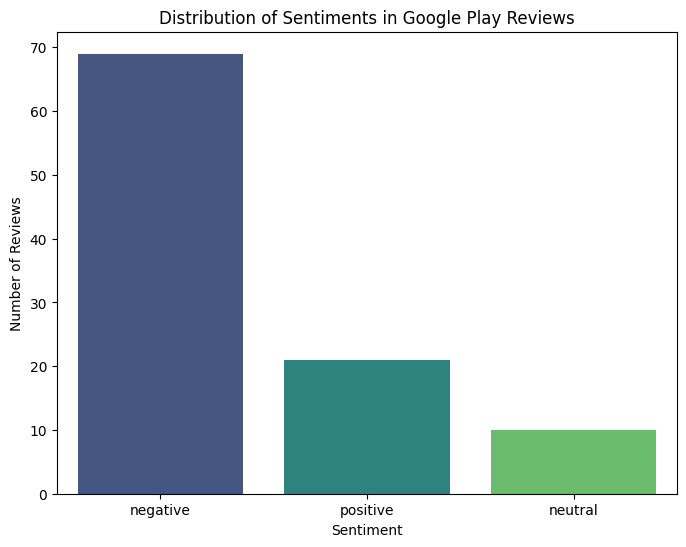

Sentiment Distribution:
sentiment
negative    69
positive    21
neutral     10
Name: count, dtype: int64


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_counts = df['sentiment'].value_counts(dropna=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title('Distribution of Sentiments in Google Play Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

print("Sentiment Distribution:")
print(sentiment_counts)